#### ⏰ Deadline: Wednesday, July 8, 20:00
### What is this notebook about?

**The story so far**




🚀 Time to get started! 

---


### **Important** 

Please note that the notebook contains images that will show when viewing them online in the Jupyter Book but may not show once you download the notebook. So, please consult the web version to view the images for stations that rely on them: https://mbp-lab.github.io/sose26-real-world-problems-ai/uncertainty/

---
#### 🟢 Station 1 -  Comparing two models

As we learned in the previous notebook, the ML team did everything they could to assess and improve the calibration of the undisclosed model. However, since they did not have access to the model itself, they could only recalibrate its predictions post hoc. As a next step, they decide to train their own model. 

(For the sake of this exercise), the lead of the ML team is really particular about two things: they prefer neural networks over other models and they feel really strong about regularization. Their go-to method for that is dropout. Here's a snippet from the team's internal chat. 

![Caption](../images/team-chat.png)


**Your task**

The predictions of this new model are available to you under `MLP-single-predictions.csv`.
Compare the performance of this model to the undisclosed model (`rural_screening.csv`). Specifically, calculate: 
- Model accuracy
- Calibration (use Brier score)
- Visualize whether the two models agree in their prediction scores 
- Identify patients for whom the two models disagree in their predictions when using a 0.5 decision threshold. Which model makes the correct prediction in these cases?

Evaluate on the hold-out patients only (`lr_split == "validation"`).

,Model,Accuracy,Brier score,Patients referred
0,Original model,0.832,0.1483,156
1,MLP,0.832,0.1279,148


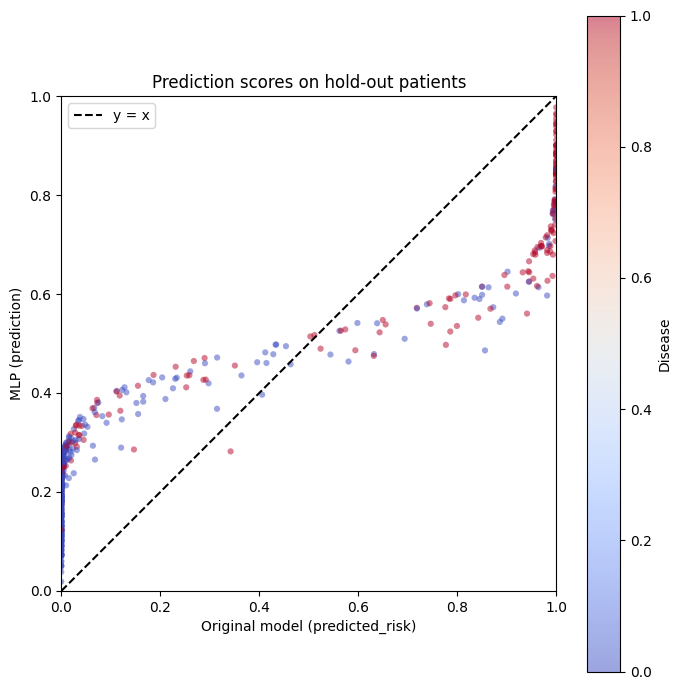

Pearson r = 0.947

Disagreements at threshold 0.5: 8 / 600
  Original correct: 4 (50.0%)
  MLP correct:      4 (50.0%)


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, brier_score_loss

THRESHOLD = 0.5

original = pd.read_csv("../data/rural_screening.csv")
mlp = pd.read_csv("../data/MLP-single-predictions.csv")

holdout = original["lr_split"] == "validation"
y = original.loc[holdout, "disease"].to_numpy()
orig_probs = original.loc[holdout, "predicted_risk"].to_numpy()
mlp_probs = mlp.loc[holdout, "prediction"].to_numpy()

comparison = []
for name, probs in [("Original model", orig_probs), ("MLP", mlp_probs)]:
    preds = (probs >= THRESHOLD).astype(int)
    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y, preds),
        "Brier score": brier_score_loss(y, probs),
        "Patients referred": int(preds.sum()),
    })
display(pd.DataFrame(comparison).style.format({"Accuracy": "{:.3f}", "Brier score": "{:.4f}"}))

fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(orig_probs, mlp_probs, c=y, cmap="coolwarm", alpha=0.5, s=20, edgecolors="none")
ax.plot([0, 1], [0, 1], "k--", label="y = x")
ax.set(xlabel="Original model (predicted_risk)", ylabel="MLP (prediction)",
       title="Prediction scores on hold-out patients", xlim=(0, 1), ylim=(0, 1), aspect="equal")
ax.legend(loc="upper left")
plt.colorbar(sc, ax=ax, label="Disease")
plt.tight_layout()
plt.show()

print(f"Pearson r = {np.corrcoef(orig_probs, mlp_probs)[0, 1]:.3f}")

orig_preds = (orig_probs >= THRESHOLD).astype(int)
mlp_preds = (mlp_probs >= THRESHOLD).astype(int)
disagree = orig_preds != mlp_preds
n_disagree = int(disagree.sum())
orig_correct = int((y[disagree] == orig_preds[disagree]).sum())
mlp_correct = int((y[disagree] == mlp_preds[disagree]).sum())

print(f"\nDisagreements at threshold {THRESHOLD}: {n_disagree} / {len(y)}")
if n_disagree:
    print(f"  Original correct: {orig_correct} ({100 * orig_correct / n_disagree:.1f}%)")
    print(f"  MLP correct:      {mlp_correct} ({100 * mlp_correct / n_disagree:.1f}%)")

---
#### 🟢🟢 Station 2 - Model uncertainty

**From calibration to uncertainty**

Model calibration tells us whether the probabilities produced by a model are meaningful on average. However, when making a decision for a single patient, another question arises: if we trained a slightly different version of the model, would it reach the same conclusion? If the answer is yes, we may have more confidence in the prediction. If not, we may want to inspect the case more carefully. In other words, the prediction score tells us the estimated risk, and calibration tells us whether that risk is meaningful. What we still do not know is how robust the prediction is.

**Breaking rules: from dropout to MC-dropout**


Here is where the concept of dropout can be extended beyond regularization. In Station 1, dropout helped prevent overfitting by randomly deactivating a subset of neurons during each training pass. This encourages the network to learn more general patterns instead of relying too heavily on a small number of neurons. 

Normally, dropout is switched off after training so that the model produces one deterministic prediction for each patient.  But what if we deliberately "break" that rule? By keeping dropout active during inference—a technique known as Monte Carlo (MC) Dropout—each forward pass uses a slightly different subset of neurons. As a result, the same patient receives multiple prediction scores rather than just one. The agreement (or disagreement) between these predictions provides an estimate of how robust the model's prediction is.


**Your task**
- Load the MC Dropout predictions from `MLP-multiple-predictions.csv`
- Visualize both the prediction scores (average across models) and the uncertainty (standard deviation of the scores) of these predictions
- Make a scatter plot of the dataset and color each dot based on its uncertainty measure. 


Patients: 3000 | MC passes: 50
Mean prediction: 0.036 – 0.973
Uncertainty (std): 0.026 – 0.145


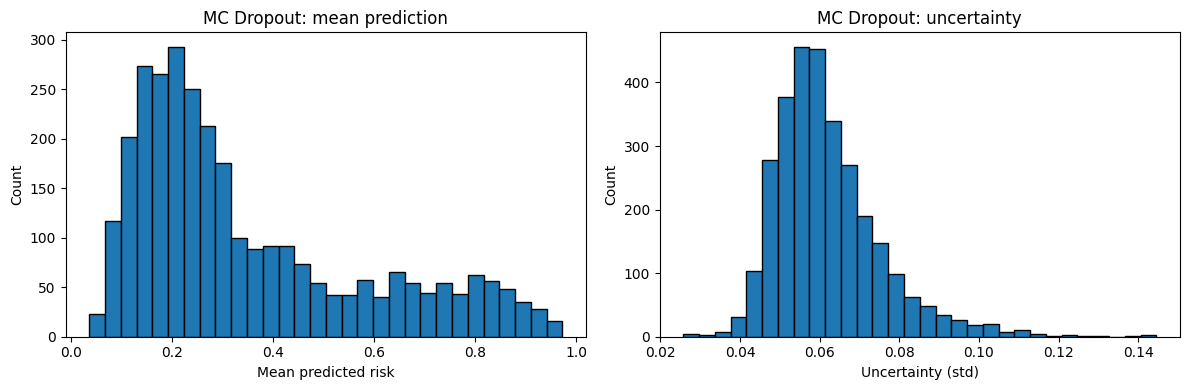

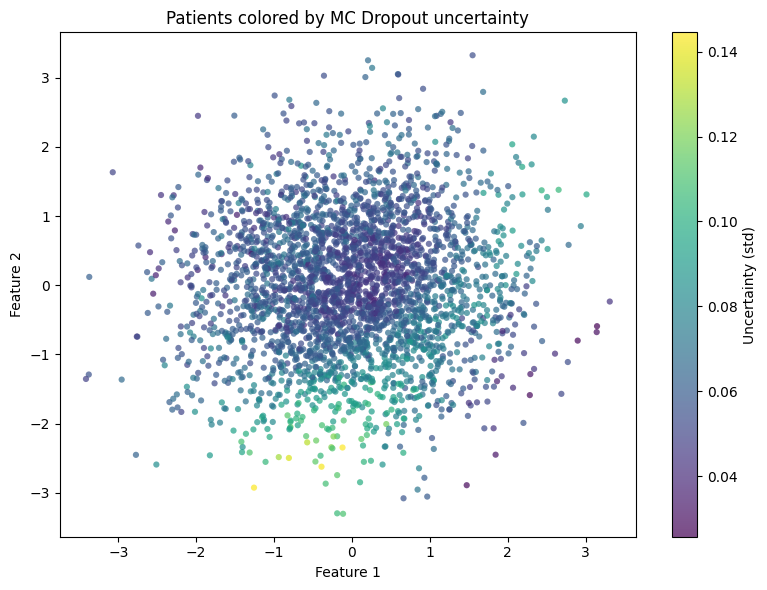

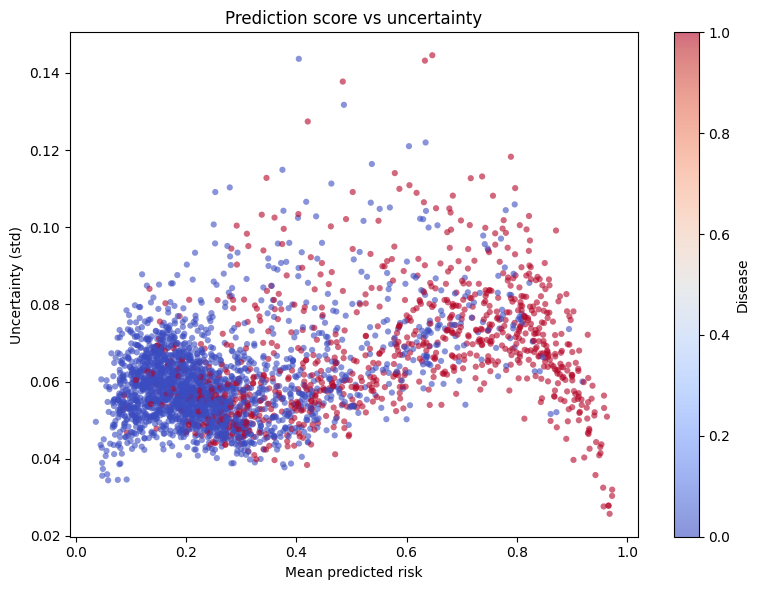

,feature 1,feature 2,disease,mean_prediction,uncertainty
2170,-0.120215,-2.344622,1,0.646752,0.144563
2357,-1.256827,-2.924578,0,0.404591,0.143642
398,-0.389892,-2.622043,1,0.633347,0.143170
2871,-0.809045,-2.495541,1,0.484330,0.137745
1621,-0.573801,-2.270240,0,0.486398,0.131717
1402,-0.938930,-2.483278,1,0.420837,0.127401
2442,-0.263516,-2.340438,0,0.634583,0.121958
1899,-0.236308,-2.185328,0,0.604400,0.121004
1210,0.441880,-2.005858,1,0.789349,0.118267
2656,-0.458591,-2.243449,0,0.537120,0.116385


In [2]:
mc = pd.read_csv("../data/MLP-multiple-predictions.csv")

pred_cols = [c for c in mc.columns if c.startswith("prediction_")]
samples = mc[pred_cols].to_numpy()
mean_pred = samples.mean(axis=1)
uncertainty = samples.std(axis=1)

print(f"Patients: {len(mc)} | MC passes: {len(pred_cols)}")
print(f"Mean prediction: {mean_pred.min():.3f} – {mean_pred.max():.3f}")
print(f"Uncertainty (std): {uncertainty.min():.3f} – {uncertainty.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mean_pred, bins=30, edgecolor="black")
axes[0].set(xlabel="Mean predicted risk", ylabel="Count", title="MC Dropout: mean prediction")
axes[1].hist(uncertainty, bins=30, edgecolor="black")
axes[1].set(xlabel="Uncertainty (std)", ylabel="Count", title="MC Dropout: uncertainty")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(mc["feature 1"], mc["feature 2"], c=uncertainty, cmap="viridis", alpha=0.7, s=20, edgecolors="none")
ax.set(xlabel="Feature 1", ylabel="Feature 2", title="Patients colored by MC Dropout uncertainty")
plt.colorbar(sc, ax=ax, label="Uncertainty (std)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(mean_pred, uncertainty, c=mc["disease"], cmap="coolwarm", alpha=0.6, s=20, edgecolors="none")
ax.set(xlabel="Mean predicted risk", ylabel="Uncertainty (std)", title="Prediction score vs uncertainty")
plt.colorbar(sc, ax=ax, label="Disease")
plt.tight_layout()
plt.show()

top_uncertain = mc.assign(mean_prediction=mean_pred, uncertainty=uncertainty)
display(top_uncertain.nlargest(10, "uncertainty")[["feature 1", "feature 2", "disease", "mean_prediction", "uncertainty"]])

### 💡 Station 2 - Reflection
What relationship do you observe between prediction score and uncertainty? Would you expect this relationship to hold for every model and dataset? Why or why not? Were you surprised by any patients with high uncertainty or low uncertainty?

---
#### 🟢🟢🟢 Station 3 - We don't want convoluted numbers - we want guarantees!


As you see, there were a lot of analyses done to troubleshoot this screening system. But the medical team has had enough! They are confused by all these numbers and concepts and have arrived at a clear conclusion: "We want an accuracy of at least 95% before we trust this model on a single patient. If the AI is unsure, pass the file to a human."

**Your task**

Implement a selective prediction simulation by varying an uncertainty threshold. Keep patients whose MC Dropout std is at or below the threshold; refer the rest to a human specialist.

For each threshold, calculate:
- the coverage: what fraction of patients is kept 
- the accuracy on the remaining (kept) patients only
- plot how these two change with the threshold

![Caption](../images/referral.png)


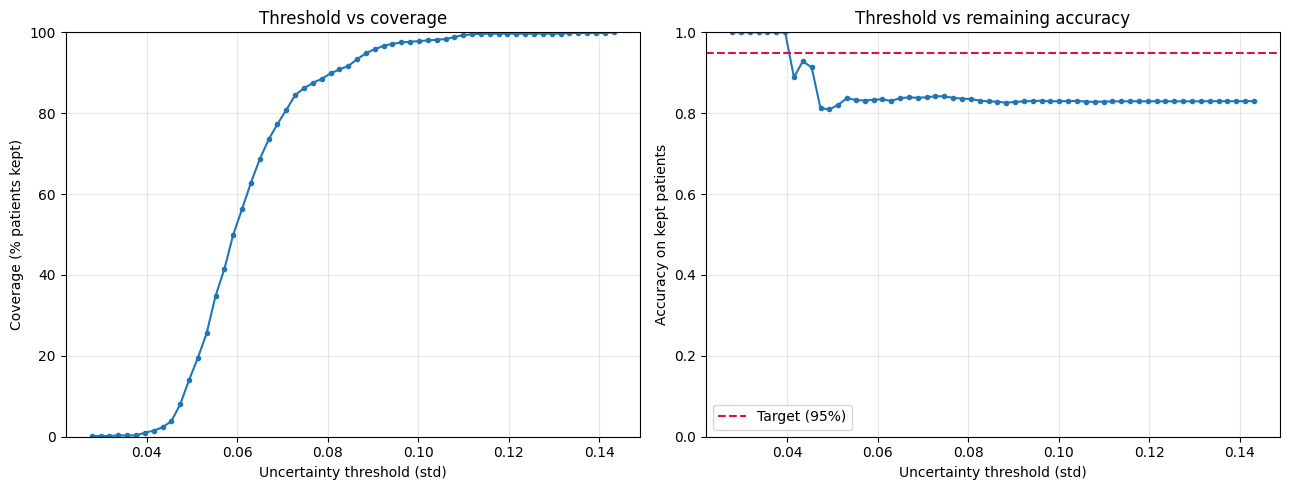

To reach ≥95% accuracy:
  Max std threshold: 0.040
  Keep 1.0% → refer 99.0% to humans
  Accuracy on kept patients: 1.000


In [3]:
THRESHOLD = 0.5
TARGET_ACCURACY = 0.95

original = pd.read_csv("../data/rural_screening.csv")
holdout_mask = original["lr_split"] == "validation"

y = mc.loc[holdout_mask, "disease"].to_numpy()
mean_holdout = mean_pred[holdout_mask.to_numpy()]
unc_holdout = uncertainty[holdout_mask.to_numpy()]
preds_holdout = (mean_holdout >= THRESHOLD).astype(int)
n_total = len(y)

std_thresholds = np.linspace(unc_holdout.min(), unc_holdout.max(), 60)
rows = []
for std_thresh in std_thresholds:
    keep = unc_holdout <= std_thresh
    n_kept = int(keep.sum())
    if n_kept == 0:
        continue
    rows.append({
        "std_threshold": std_thresh,
        "coverage": n_kept / n_total,
        "accuracy": accuracy_score(y[keep], preds_holdout[keep]),
    })
selective_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(selective_df["std_threshold"], selective_df["coverage"] * 100, "o-", markersize=3)
axes[0].set(xlabel="Uncertainty threshold (std)", ylabel="Coverage (% patients kept)",
            title="Threshold vs coverage", ylim=(0, 100))
axes[0].grid(alpha=0.3)

axes[1].plot(selective_df["std_threshold"], selective_df["accuracy"], "o-", markersize=3)
axes[1].axhline(TARGET_ACCURACY, color="crimson", linestyle="--", label=f"Target ({TARGET_ACCURACY:.0%})")
axes[1].set(xlabel="Uncertainty threshold (std)", ylabel="Accuracy on kept patients",
            title="Threshold vs remaining accuracy", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

meets_target = selective_df[selective_df["accuracy"] >= TARGET_ACCURACY]
if len(meets_target):
    best = meets_target.loc[meets_target["std_threshold"].idxmax()]
    print(f"To reach ≥{TARGET_ACCURACY:.0%} accuracy:")
    print(f"  Max std threshold: {best['std_threshold']:.3f}")
    print(f"  Keep {best['coverage']*100:.1f}% → refer {100 - best['coverage']*100:.1f}% to humans")
    print(f"  Accuracy on kept patients: {best['accuracy']:.3f}")
else:
    best = selective_df.loc[selective_df["accuracy"].idxmax()]
    print(f"≥{TARGET_ACCURACY:.0%} not reachable. Best: {best['accuracy']:.1%} at std ≤ {best['std_threshold']:.3f}")

### 💡 Station 3 - Reflection
What is your final verdict? Is the model useful? What would you do next?